**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Luis Felipe García Domínguez

# Tarea 2: Preprocesamiento de Datos
## Dataset: Breast Cancer Wisconsin (Original)

## 1. Bibliotecas

Importamos las herramientas básicas para trabajar con tablas (`pandas`, `numpy`) y para generar gráficos (`matplotlib`, `seaborn`).

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuracion de estilo para las graficas
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Manejo de warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Carga de datos y diccionario de variables

El conjunto de datos contiene información de biopsias realizadas a pacientes con sospecha de cáncer de mama (Dr. William H. Wolberg, Universidad de Wisconsin).

### Unidad de análisis
Cada fila representa la muestra de una masa mamaria tomada con aguja fina. A través del microscopio se calificaron 9 características de las células con números del **1 al 10**, donde 1 representa células normales y 10 células con alteraciones severas.

### Diccionario de variables

| Variable | Tipo | Rango | Descripción |
|---|---|---|---|
| `id` | Entero | N/A | Código de identificación de la muestra |
| `clump_thickness` | Numérico | 1 - 10 | Grosor del grupo de células |
| `uniformity_cell_size` | Numérico | 1 - 10 | Uniformidad en el tamaño celular |
| `uniformity_cell_shape` | Numérico | 1 - 10 | Uniformidad en la forma celular |
| `marginal_adhesion` | Numérico | 1 - 10 | Adhesión entre células vecinas |
| `single_epithelial_size`| Numérico | 1 - 10 | Tamaño de la célula epitelial |
| `bare_nuclei` | Numérico | 1 - 10 | Núcleos desnudos (algunos faltantes como `'?'`) |
| `bland_chromatin` | Numérico | 1 - 10 | Textura del núcleo celular |
| `normal_nucleoli` | Numérico | 1 - 10 | Tamaño y presencia de nucléolos |
| `mitoses` | Numérico | 1 - 10 | Ritmo de división celular |
| `class` | Categórico | 2 ó 4 | Diagnóstico médico: `2 = Benigno`, `4 = Maligno` |

In [30]:
# Lista con los nombres de las columnas
columnas = [
    'id',
    'clump_thickness',
    'uniformity_cell_size',
    'uniformity_cell_shape',
    'marginal_adhesion',
    'single_epithelial_size',
    'bare_nuclei',
    'bland_chromatin',
    'normal_nucleoli',
    'mitoses',
    'class'
]

# Cargamos los datos indicando que el signo '?' representa valores faltantes
df = pd.read_csv('../data/breast-cancer-wisconsin.data', header=None, names=columnas, na_values='?')

# Agregamos una columna de texto para leer el diagnostico con facilidad
df['diagnostico'] = df['class'].map({2: 'Benigno', 4: 'Maligno'})

print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

El dataset tiene 699 filas y 12 columnas.


,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class,diagnostico
0,1000025,5,1,1,1,2,1.0,3,1,1,2,Benigno
1,1002945,5,4,4,5,7,10.0,3,2,1,2,Benigno
2,1015425,3,1,1,1,2,2.0,3,1,1,2,Benigno
3,1016277,6,8,8,1,3,4.0,3,7,1,2,Benigno
4,1017023,4,1,1,3,2,1.0,3,1,1,2,Benigno


## 3. Auditoría inicial y calidad de los datos

Revisamos el estado general del dataset: tipos de datos, presencia de valores nulos, registros duplicados y rangos esperados.

In [31]:
# Revision de tipos de datos y conteo de valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      699 non-null    int64  
 1   clump_thickness         699 non-null    int64  
 2   uniformity_cell_size    699 non-null    int64  
 3   uniformity_cell_shape   699 non-null    int64  
 4   marginal_adhesion       699 non-null    int64  
 5   single_epithelial_size  699 non-null    int64  
 6   bare_nuclei             683 non-null    float64
 7   bland_chromatin         699 non-null    int64  
 8   normal_nucleoli         699 non-null    int64  
 9   mitoses                 699 non-null    int64  
 10  class                   699 non-null    int64  
 11  diagnostico             699 non-null    str    
dtypes: float64(1), int64(10), str(1)
memory usage: 65.7 KB


In [32]:
# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Revision de duplicados
print("\nFilas completamente duplicadas:", df.duplicated().sum())
print("IDs repetidos (pacientes con mas de una muestra):", df['id'].duplicated().sum())

Valores nulos por columna:
id                         0
clump_thickness            0
uniformity_cell_size       0
uniformity_cell_shape      0
marginal_adhesion          0
single_epithelial_size     0
bare_nuclei               16
bland_chromatin            0
normal_nucleoli            0
mitoses                    0
class                      0
diagnostico                0
dtype: int64

Filas completamente duplicadas: 8
IDs repetidos (pacientes con mas de una muestra): 54


In [33]:
# Estadisticas descriptivas basicas de las variables numericas
df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]

,count,mean,std,min,50%,max
id,699.0,1.071704e+06,617095.729819,61634.0,1171710.0,13454352.0
clump_thickness,699.0,4.417740e+00,2.815741,1.0,4.0,10.0
uniformity_cell_size,699.0,3.134478e+00,3.051459,1.0,1.0,10.0
uniformity_cell_shape,699.0,3.207439e+00,2.971913,1.0,1.0,10.0
marginal_adhesion,699.0,2.806867e+00,2.855379,1.0,1.0,10.0
single_epithelial_size,699.0,3.216023e+00,2.214300,1.0,2.0,10.0
bare_nuclei,683.0,3.544656e+00,3.643857,1.0,1.0,10.0
bland_chromatin,699.0,3.437768e+00,2.438364,1.0,3.0,10.0
normal_nucleoli,699.0,2.866953e+00,3.053634,1.0,1.0,10.0
mitoses,699.0,1.589413e+00,1.715078,1.0,1.0,10.0


## 4. Análisis Exploratorio de Datos (EDA)

A continuación exploramos cómo se comportan las variables y cómo se diferencian las muestras benignas de las malignas.

### 4.1 Distribución de la variable objetivo (Diagnóstico)

Veamos cuántas muestras corresponden a tumores benignos y cuántas a malignos.

Conteo de casos:
diagnostico
Benigno    458
Maligno    241
Name: count, dtype: int64

Porcentajes:
diagnostico
Benigno    65.52
Maligno    34.48
Name: proportion, dtype: float64


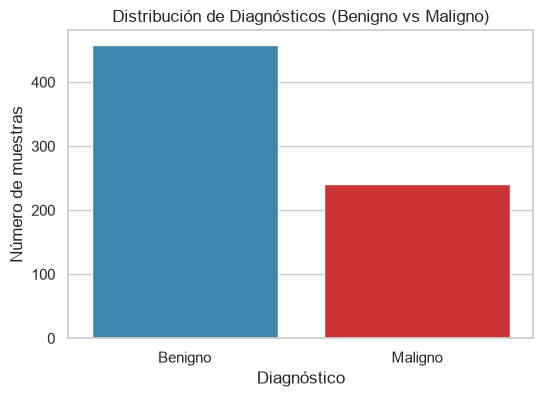

In [34]:
# Conteo y porcentajes de cada diagnostico
conteo_clases = df['diagnostico'].value_counts()
porcentajes = df['diagnostico'].value_counts(normalize=True) * 100

print("Conteo de casos:")
print(conteo_clases)
print("\nPorcentajes:")
print(porcentajes.round(2))

# Grafica de barras simple
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnostico', palette=['#2b8cbe', '#e41a1c'])
plt.title('Distribución de Diagnósticos (Benigno vs Maligno)')
plt.xlabel('Diagnóstico')
plt.ylabel('Número de muestras')
plt.show()

**Lectura.**

El conjunto de datos presenta 458 muestras correspondientes a tumores benignos (65.52%) y 241 a tumores malignos (34.48%), lo que refleja una proporción (aproximada) de dos casos benignos por cada caso maligno. Aunque este nivel de desbalance no es extremo, en medicina la clase maligna es la más crítica, ya que un falso negativo implica un mayor riesgo. Esto sugiere que podría ser conveniente considerar técnicas de balanceo o aumento de datos más adelante.

Esta observación corrobora lo mencionado en el archivo `.names` del dataset original.

### 4.2 Comparación de características entre Benigno y Maligno

Comparamos los valores de las características celulares según el diagnóstico usando diagramas de caja (boxplots). Esto nos permite ver si hay diferencias claras entre ambos grupos.

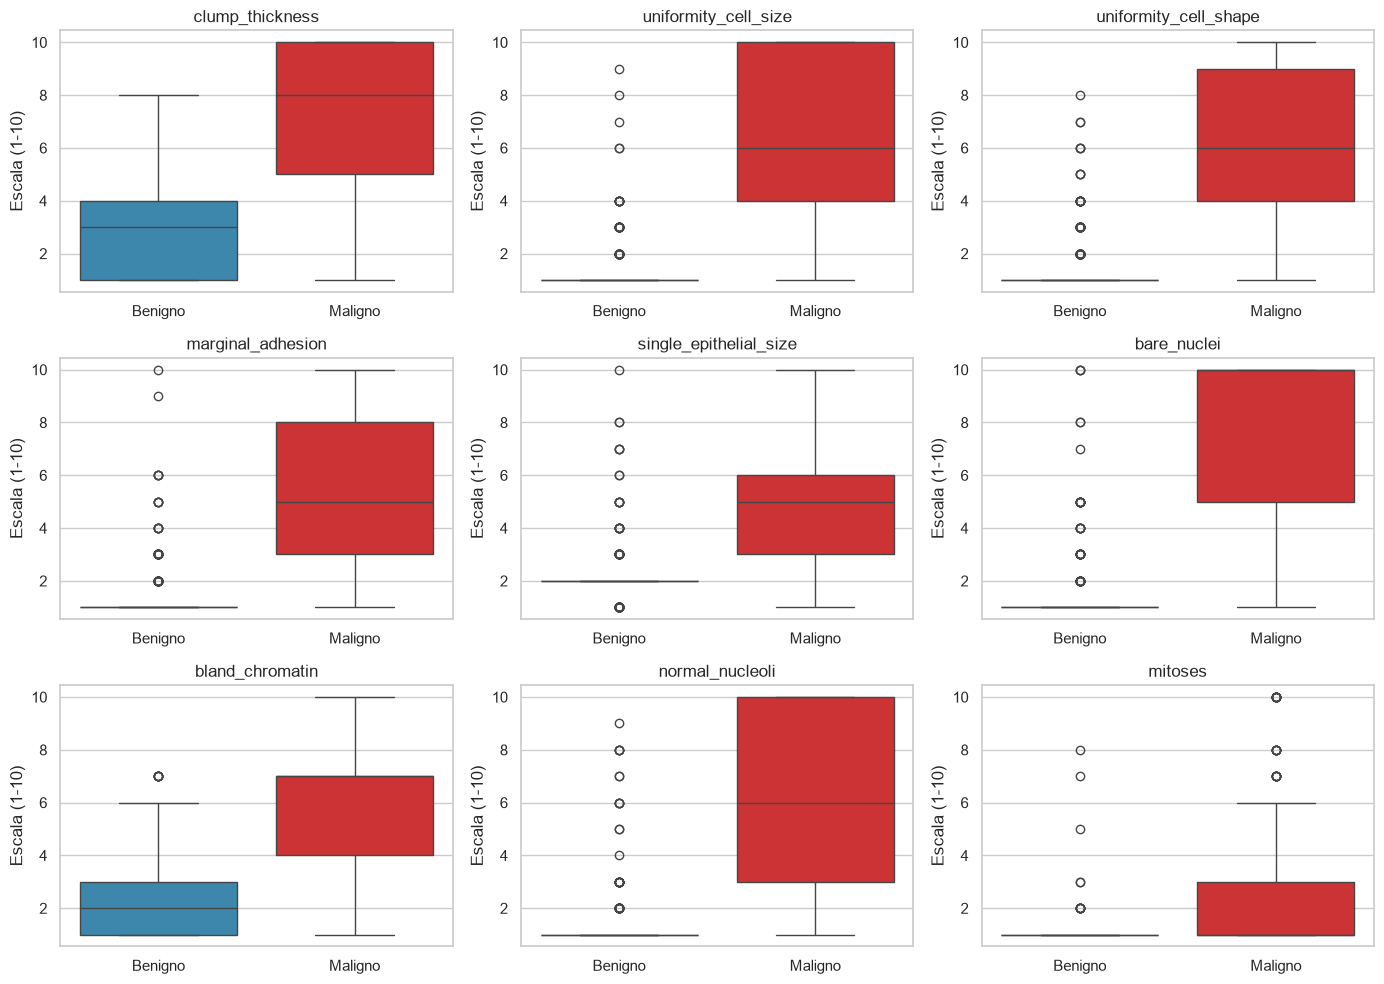

In [35]:
# Lista de las 9 caracteristicas celulares
caracteristicas = [
    'clump_thickness',
    'uniformity_cell_size',
    'uniformity_cell_shape',
    'marginal_adhesion',
    'single_epithelial_size',
    'bare_nuclei',
    'bland_chromatin',
    'normal_nucleoli',
    'mitoses'
]

# Mostramos las 9 caracteristicas en una cuadricula sencilla
plt.figure(figsize=(14, 10))
for i, col in enumerate(caracteristicas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='diagnostico', y=col, palette=['#2b8cbe', '#e41a1c'])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Escala (1-10)')

plt.tight_layout()
plt.show()

**Lectura.**

Los diagramas de caja muestran una clara separación entre diagnósticos en la mayoría de las características citológicas. En las muestras benignas los valores se concentran casi totalmente entre 1 y 2 con una dispersión muy baja, mientras que en las muestras malignas las medianas se sitúan entre 4 y 8 con mayor variabilidad.

Las variables que mejor separan ambos grupos a simple vista son la uniformidad del tamaño celular, la uniformidad de la forma celular y los núcleos desnudos.

También se observa que la mitosis presenta valores cercanos a 1 en casi todas las observaciones benignas y en gran parte de las malignas, indicando que una división celular visible elevada es poco frecuente en general, pero cuando se presenta con valores altos corresponde de forma casi exclusiva a una observación maligna.

### 4.3 Correlación entre características

Calculamos la correlación entre las 9 características celulares para saber qué variables comparten información similar.

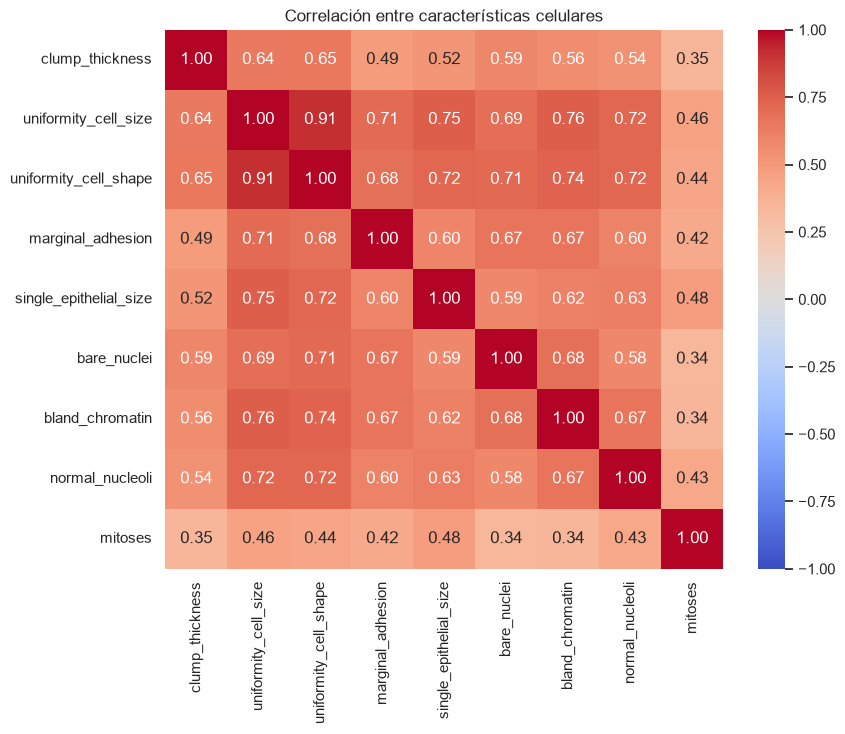

In [36]:
# Matriz de correlacion
matriz_corr = df[caracteristicas].corr()

# Mapa de calor de la correlacion
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Correlación entre características celulares')
plt.show()

**Lectura.**

La matriz de correlación muestra que todas las variables presentan relaciones positivas entre sí. La correlación que más destaca ocurre entre la uniformidad del tamaño celular y la uniformidad de la forma celular con un valor de 0.91. Esta fuerte redundancia entre columnas sugiere que podría ser viable aplicar técnicas de reducción de dimensionalidad para resumir el conjunto de datos sin perder información representativa.

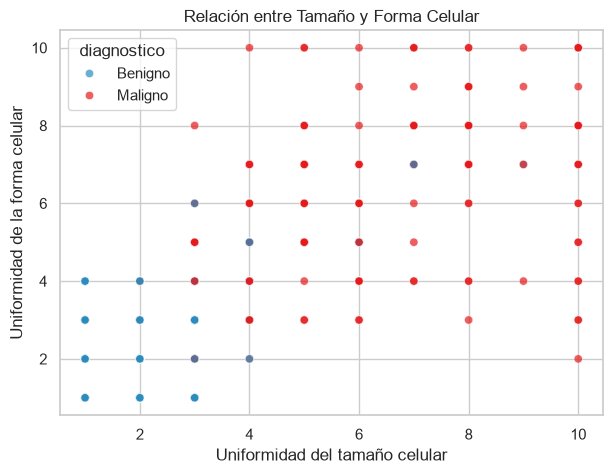

In [37]:
# Grafico de dispersion de las dos variables mas correlacionadas
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='uniformity_cell_size',
    y='uniformity_cell_shape',
    hue='diagnostico',
    palette=['#2b8cbe', '#e41a1c'],
    alpha=0.7
)
plt.title('Relación entre Tamaño y Forma Celular')
plt.xlabel('Uniformidad del tamaño celular')
plt.ylabel('Uniformidad de la forma celular')
plt.show()

**Lectura.**

El gráfico de dispersión confirma visualmente la relación lineal entre el tamaño y la forma celular. Las muestras benignas se agrupan en la esquina inferior izquierda. Por otra parte, las muestras malignas se distribuyen a lo largo de la diagonal hacia valores altos, lo que permite ver que la pérdida de uniformidad en ambas características ocurre al mismo tiempo en los tumores malignos.

## 5. Resumen de hallazgos del EDA

A partir de la exploración inicial identificamos lo siguiente (algunos puntos ya los mencionaba el archivo `.names` del dataset original):

1. **Valores faltantes:** La variable `bare_nuclei` tiene **16 valores faltantes** (representados originalmente como `'?'`). El resto de las columnas no tiene valores nulos.
2. **Identificador (`id`):** La columna `id` es solo una etiqueta administrativa y no tiene relación con el diagnóstico médico. Además, existen pacientes con más de un registro, por lo que esta columna debe descartarse antes de modelar o procesar.
3. **Desbalance de clases:** Hay **458 casos benignos (65.5%)** y **241 casos malignos (34.5%)**. Aunque no es un desbalance extremo, la clase maligna es minoritaria.
4. **Separabilidad de clases:** En casi todas las variables, los casos benignos se concentran en valores muy bajos (cercanos a 1), mientras que los casos malignos presentan valores dispersos y más altos (de 4 a 10).
5. **Redundancia entre variables:** Existe una correlación muy fuerte (0.91) entre `uniformity_cell_size` y `uniformity_cell_shape`, lo que sugiere que ambas aportan información muy similar y abre la puerta a técnicas de reducción de dimensionalidad.

## 6. Técnica 1: Limpieza de datos (Imputación y Escalado)

En esta sección aplicamos el primer tipo de procesamiento requerido. Con base en los hallazgos del EDA, implementamos tres acciones de limpieza:

1. **Eliminación del identificador (`id`):** Al tratarse de un código que no contiene información, se retira del análisis para evitar introducir ruido.
2. **Imputación de valores faltantes en `bare_nuclei`:** Se utiliza la **mediana** como valor que reemplazará 16 registros faltantes. Al ser una escala discreta (1 a 10) concentrada en valores bajos, la mediana conserva la tendencia central sin verse afectada por los valores extremos.
3. **Escalado de características (`MinMaxScaler`):** Las 9 variables se transforman al intervalo cerrado [0, 1]. Esto hace homogenea la escala de las mediciones al mismo tiempo que conserva las distancias relativas entre observaciones.

In [38]:
from sklearn.preprocessing import MinMaxScaler

# Copia de trabajo para mantener intacto el dataframe original
df_limpio = df.copy()

# 1. Eliminamos la columna id
df_limpio = df_limpio.drop(columns=["id"])

# Guardamos la serie original antes de imputar para la comparacion visual
bare_nuclei_antes = df_limpio["bare_nuclei"].copy()

# 2. Imputacion con la mediana
mediana_nuclei = df_limpio["bare_nuclei"].median()
df_limpio["bare_nuclei"] = df_limpio["bare_nuclei"].fillna(mediana_nuclei)

print(f"Mediana utilizada para imputar bare_nuclei: {mediana_nuclei}")
print(f"Valores faltantes antes de imputar: {bare_nuclei_antes.isnull().sum()}")
print(f"Valores faltantes despues de imputar: {df_limpio["bare_nuclei"].isnull().sum()}")

# 3. Escalado MinMaxScaler al intervalo [0, 1]
scaler = MinMaxScaler()
df_escalado = df_limpio.copy()
df_escalado[caracteristicas] = scaler.fit_transform(df_limpio[caracteristicas])

print("Primeras 5 filas con datos limpios y escalados:")
df_escalado[caracteristicas].head()

Mediana utilizada para imputar bare_nuclei: 1.0
Valores faltantes antes de imputar: 16
Valores faltantes despues de imputar: 0
Primeras 5 filas con datos limpios y escalados:


,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses
0,0.444444,0.000000,0.000000,0.000000,0.111111,0.000000,0.222222,0.000000,0.0
1,0.444444,0.333333,0.333333,0.444444,0.666667,1.000000,0.222222,0.111111,0.0
2,0.222222,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.000000,0.0
3,0.555556,0.777778,0.777778,0.000000,0.222222,0.333333,0.222222,0.666667,0.0
4,0.333333,0.000000,0.000000,0.222222,0.111111,0.000000,0.222222,0.000000,0.0


### Comparación visual: Antes y después de la Limpieza

A continuación contrastamos cómo se veían los datos antes y después de aplicar la imputación y el escalado.

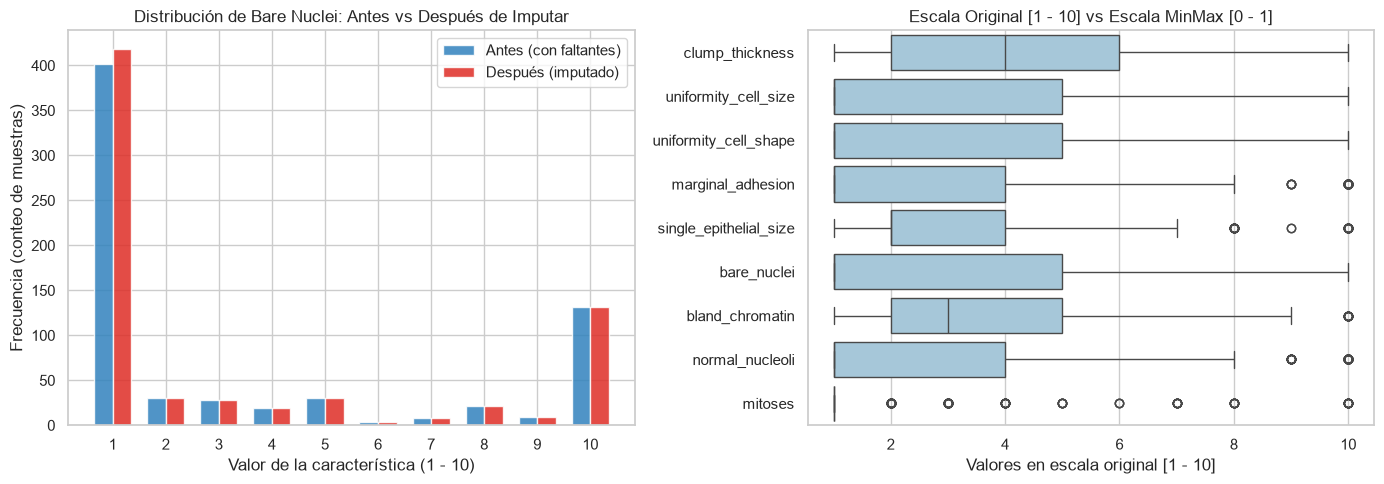

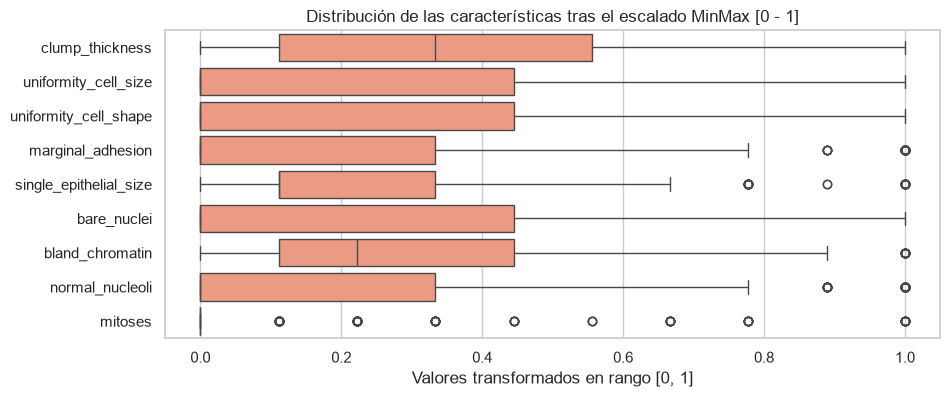

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Imputacion de bare_nuclei (Antes vs Despues)
conteo_antes = bare_nuclei_antes.value_counts().sort_index()
conteo_despues = df_limpio["bare_nuclei"].value_counts().sort_index()

ancho = 0.35
x = np.arange(1, 11)

axes[0].bar(x - ancho/2, [conteo_antes.get(i, 0) for i in x], width=ancho, label="Antes (con faltantes)", color="#3182bd", alpha=0.85)
axes[0].bar(x + ancho/2, [conteo_despues.get(i, 0) for i in x], width=ancho, label="Después (imputado)", color="#de2d26", alpha=0.85)
axes[0].set_title("Distribución de Bare Nuclei: Antes vs Después de Imputar")
axes[0].set_xlabel("Valor de la característica (1 - 10)")
axes[0].set_ylabel("Frecuencia (conteo de muestras)")
axes[0].set_xticks(x)
axes[0].legend()

# Panel 2: Efecto del Escalado en las caracteristicas (Antes vs Despues)
sns.boxplot(data=df_limpio[caracteristicas], ax=axes[1], color="#9ecae1", orient="h")
axes[1].set_title("Escala Original [1 - 10] vs Escala MinMax [0 - 1]")
axes[1].set_xlabel("Valores en escala original [1 - 10]")

plt.tight_layout()
plt.show()

# Grafico adicional para visualizar la escala normalizada [0, 1]
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_escalado[caracteristicas], color="#fc9272", orient="h")
plt.title("Distribución de las características tras el escalado MinMax [0 - 1]")
plt.xlabel("Valores transformados en rango [0, 1]")
plt.show()

**Lectura.**

La comparación visual de la imputación muestra que la distribución original de núcleos desnudos se mantuvo prácticamente idéntica, con el único cambio visible en el valor 1, donde se concentraron los 16 registros imputados al coincidir con la mediana del conjunto. Esto evitó distorsionar la forma general de los datos y permitió conservar la totalidad de las 699 observaciones sin pérdida de información.

Por otra parte, los gráficos de caja muestran que el escalado (MinMaxScaler) comprimió el rango de las 9 variables de su intervalo entero original de 1 a 10 hacia un rango de 0 a 1, conservando las asimetrías y distancias relativas de cada variable, pero facilitando que métodos sensibles a magnitudes operen en condiciones iguales.

## 7. Técnica 2: Reducción de dimensionalidad (PCA)

En el EDA se observó una alta correlación entre varias características celulares (por ejemplo, 0.91 entre tamaño y forma celular), lo que indica la existencia de información redundante en el espacio original de 9 dimensiones.

Para simplificar la estructura del conjunto de datos sin perder información crítica, aplicamos **Análisis de Componentes Principales (PCA)**. Esta técnica proyecta las 9 variables continuas sobre un nuevo conjunto de ejes perpendiculares (no correlacionados) llamados componentes principales, orientados en las direcciones de máxima dispersión de los datos.

In [40]:
from sklearn.decomposition import PCA

# 1. Ajuste de PCA con 2 componentes sobre las caracteristicas escaladas
pca_2 = PCA(n_components=2, random_state=42)
X_pca = pca_2.fit_transform(df_escalado[caracteristicas])

# Guardamos las proyecciones en un DataFrame para graficar
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["diagnostico"] = df_limpio["diagnostico"].values

# 2. Calculo de varianza explicada
var_pc1 = pca_2.explained_variance_ratio_[0] * 100
var_pc2 = pca_2.explained_variance_ratio_[1] * 100
var_acum = var_pc1 + var_pc2

print(f"Varianza explicada por PC1: {var_pc1:.2f}%")
print(f"Varianza explicada por PC2: {var_pc2:.2f}%")
print(f"Varianza acumulada en 2 componentes: {var_acum:.2f}%")

# 3. PCA completo para observar la distribucion de varianza de todas las componentes
pca_full = PCA(random_state=42)
pca_full.fit(df_escalado[caracteristicas])
var_todas = pca_full.explained_variance_ratio_ * 100

Varianza explicada por PC1: 68.90%
Varianza explicada por PC2: 7.34%
Varianza acumulada en 2 componentes: 76.24%


### Comparación visual: Antes y después de la Reducción de Dimensionalidad

Contrastamos el espacio original en dos variables correlacionadas (antes) frente al nuevo espacio generado por las dos primeras componentes principales de PCA (después).

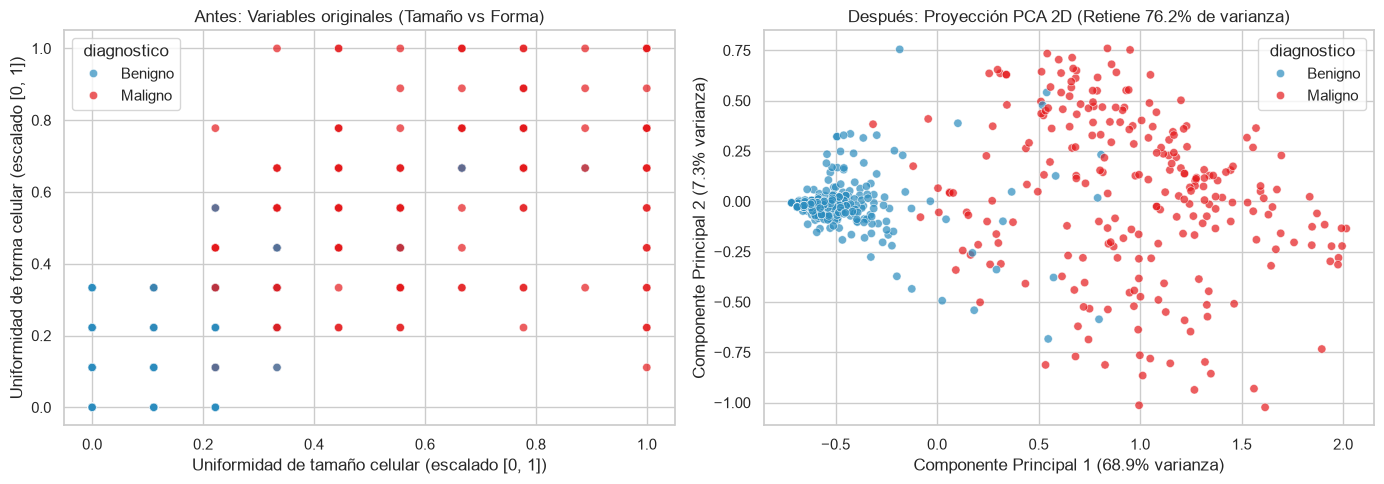

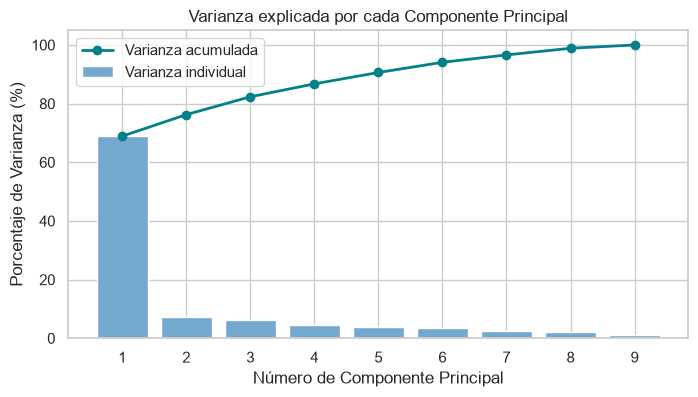

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica Antes: Espacio original en 2 variables correlacionadas
sns.scatterplot(
    data=df_escalado,
    x="uniformity_cell_size",
    y="uniformity_cell_shape",
    hue="diagnostico",
    palette=["#2b8cbe", "#e41a1c"],
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Antes: Variables originales (Tamaño vs Forma)")
axes[0].set_xlabel("Uniformidad de tamaño celular (escalado [0, 1])")
axes[0].set_ylabel("Uniformidad de forma celular (escalado [0, 1])")

# Grafica Despues: Proyeccion 2D con PCA (PC1 vs PC2)
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="diagnostico",
    palette=["#2b8cbe", "#e41a1c"],
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title(f"Después: Proyección PCA 2D (Retiene {var_acum:.1f}% de varianza)")
axes[1].set_xlabel(f"Componente Principal 1 ({var_pc1:.1f}% varianza)")
axes[1].set_ylabel(f"Componente Principal 2 ({var_pc2:.1f}% varianza)")

plt.tight_layout()
plt.show()

# Grafica de apoyo: Varianza conservada por componente
plt.figure(figsize=(8, 4))
componentes = np.arange(1, len(var_todas) + 1)
plt.bar(componentes, var_todas, color="#74a9cf", label="Varianza individual")
plt.plot(componentes, np.cumsum(var_todas), color="#02818a", marker="o", linewidth=2, label="Varianza acumulada")
plt.title("Varianza explicada por cada Componente Principal")
plt.xlabel("Número de Componente Principal")
plt.ylabel("Porcentaje de Varianza (%)")
plt.xticks(componentes)
plt.legend()
plt.show()

**Lectura.**

La proyección por PCA muestra que las dos primeras componentes principales logran retener el 76.24% de la variabilidad total de las 9 características, con la primera componente aportando por sí sola el 68.90% de la información.

Al comparar las figuras se aprecia que, mientras el gráfico previo mostraba dos variables individuales limitadas por una marcada diagonal, el espacio de dos dimensiones de PCA sintetiza el estado morfológico de las células.

A lo largo del eje horizontal de la primera componente se distingue una frontera marcada entre ambas clases, ubicando a los tumores benignos en valores negativos y a los tumores malignos en valores positivos y dispersos, demostrando que fue posible reducir la dimensionalidad en casi un 78% sin comprometer la capacidad de discriminar entre diagnósticos.

## 8. Validación final

A continuación se presenta la validación del conjunto final.

In [42]:
# Verificacion de calidad del conjunto limpio y preparado
print("=== VALIDACIÓN FINAL DEL CONJUNTO DE DATOS ===")
print(f"Filas totales: {df_escalado.shape[0]}")
print(f"Columnas totales: {df_escalado.shape[1]} (9 predictoras + class + diagnostico)")
print(f"Valores nulos en todo el DataFrame: {df_escalado.isnull().sum().sum()}")
print("\nDistribución de clases preservada:")
print(df_escalado["diagnostico"].value_counts())

# Vista final de las primeras filas
print("\nPrimeras observaciones del conjunto final:")
df_escalado.head()

=== VALIDACIÓN FINAL DEL CONJUNTO DE DATOS ===
Filas totales: 699
Columnas totales: 11 (9 predictoras + class + diagnostico)
Valores nulos en todo el DataFrame: 0

Distribución de clases preservada:
diagnostico
Benigno    458
Maligno    241
Name: count, dtype: int64

Primeras observaciones del conjunto final:


,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class,diagnostico
0,0.444444,0.000000,0.000000,0.000000,0.111111,0.000000,0.222222,0.000000,0.0,2,Benigno
1,0.444444,0.333333,0.333333,0.444444,0.666667,1.000000,0.222222,0.111111,0.0,2,Benigno
2,0.222222,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.000000,0.0,2,Benigno
3,0.555556,0.777778,0.777778,0.000000,0.222222,0.333333,0.222222,0.666667,0.0,2,Benigno
4,0.333333,0.000000,0.000000,0.222222,0.111111,0.000000,0.222222,0.000000,0.0,2,Benigno


## 9. Conclusiones

El análisis inicial de los datos de Wisconsin fue clave para entenderlos y decidir cómo prepararlos. El proceso consistió en dos pasos principales:

**Limpieza y ajuste de datos:** Reemplazamos 16 valores faltantes en la variable de núcleos desnudos usando la mediana para no perder información valiosa. Además, eliminamos el identificador y ajustamos todas las variables a una escala de 0 a 1 (usando MinMaxScaler) para que los modelos (pensando a futuro) puedan compararlas correctamente.

**Reducción de variables (PCA):** Como las 9 características celulares medían aspectos muy similares, las resumimos en solo 2 componentes principales. Este paso conservó el 76.24% de la información original, redujo la complejidad de los datos y permitió separar claramente las muestras benignas de las malignas.

---
### Declaración sobre el uso de IA Generativa

Este notebook fue laborado con apoyo de modelos de lenguaje basados en IA (Gemini / Antigravity) como herramientas de apoyo para la depuración de código, revisión de textos y formato markdown. El razonamiento analítico, el planteamiento metodológico, la interpretación de resultados y la redacción final de los hallazgos son responsabilidad del autor.